# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [3]:
# Import scene as xml file
scene = load_scene("WindowsConfig/WindowsConfig.xml")

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

tx = Transmitter("tx", [5, 3, 1.5])
scene.add(tx)

rx1 = Receiver("rx", [-10, -10, 1.5])
rx2 = Receiver("rx2", [-10, 10, 1.5])
rx3 = Receiver("rx3", [10, -10, 1.5])
rx4 = Receiver("rx4", [10, 10, 1.5])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)

scene.preview()

In [8]:
# mi.set_variant("llvm_ad_mono_polarized")
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[0.2,0.2],
               samples_per_tx=10**8)

In [9]:
scene.preview(radio_map=rm)

In [25]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=7)

In [26]:
scene.preview(paths=paths)

[[[6.62106e-08, 6.75383e-08, 6.68702e-08, .. 186 skipped .., -1, -1, -1]],
 [[5.70346e-08, 5.52147e-08, 1.65436e-07, .. 186 skipped .., -1, -1, -1]],
 [[7.92859e-08, 4.64601e-08, 7.428e-08, .. 186 skipped .., -1, -1, -1]],
 [[2.86943e-08, 3.64013e-08, 3.81913e-08, .. 186 skipped .., 6.40565e-08, 1.34749e-07, 4.23048e-08]]]


<Figure size 2000x2000 with 0 Axes>

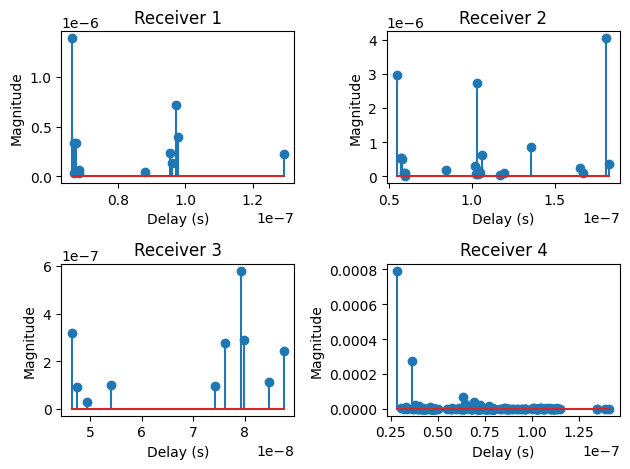

In [38]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=10e6,
                num_time_steps=1,
                normalize_delays=False)


coeffs_re, coeffs_im = cir[0]
delays = cir[1]

print(delays)

coeffs_re = coeffs_re[..., 0]
coeffs_im = coeffs_im[..., 0]
delays = delays[..., :].numpy()

magnitudes = np.abs(coeffs_re.numpy() + 1j*coeffs_im.numpy())
magnitudes = magnitudes.reshape(magnitudes.shape[0], -1)
delays = delays.reshape(delays.shape[0], -1)

# Removing points corresponding to -1 delay (no path)
mag_ = magnitudes
del_ = delays
magnitudes = []
delays = []
for i in range(mag_.shape[0]):
    mask = del_[i] >= 0
    delays.append(del_[i][mask])
    magnitudes.append(mag_[i][mask])


plt.figure(figsize=(20,20))
plt.subplots(2,2)

plt.subplot(2,2,1)
plt.stem(delays[0], magnitudes[0])
plt.title("Receiver 1")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,2)
plt.stem(delays[1], magnitudes[1])
plt.title("Receiver 2")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,3)
plt.stem(delays[2], magnitudes[2])
plt.title("Receiver 3")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.subplot(2,2,4)
plt.stem(delays[3], magnitudes[3])
plt.title("Receiver 4")
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

In [ ]:
# Filtering out small magnitudes